In [106]:
import numpy as np
import matplotlib.pyplot as plt

## Задача 1

Напишите общую функцию для градиентного спуска. На вход функция принимает в числе прочего оптимизируемую функцию и ее производную

In [107]:
def f(w):
    return w ** 2 + 2 * w + 5

def fd(w):
    return 2 * w + 2

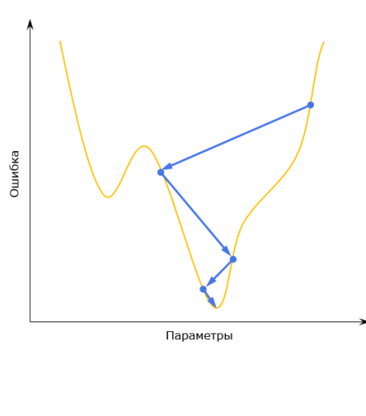

In [108]:
def gradient_descent(f, fd, learning_rate, num_steps, w_0):
    losses = []      # завели массив значений функции потерь
    ws = [w_0]       # массив шагов
    w_cur = w_0
    for step in range(num_steps):
        loss_step = f(w_cur)
        g = fd(w_cur)
        w_cur = w_cur - learning_rate * g
        losses.append(loss_step)
        ws.append(w_cur)
    losses.append(f(w_cur))
    return losses, ws, w_cur

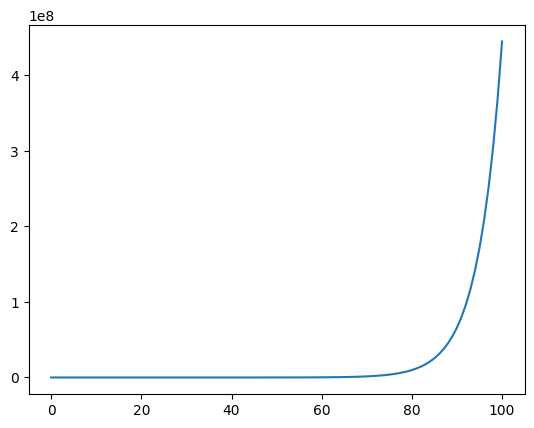

In [109]:
loss, wh, w = gradient_descent(f, fd, 1.05, 100, np.random.random())
plt.plot(loss)


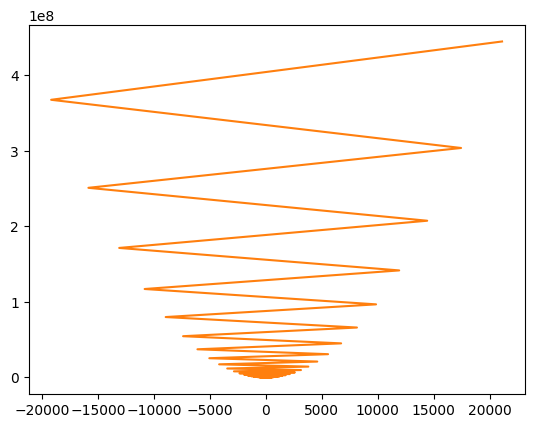

In [110]:
w = np.arange(-2, 2, 0.001)
y = f(w)
plt.plot(w,y)
plt.plot(wh, loss)

## Задача 2

Посмотрите, как влияет learning rate на поиск минимума функции

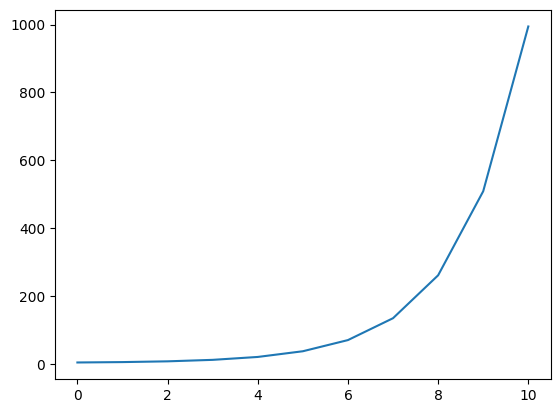

In [111]:
loss, wh, w = gradient_descent(f, fd, 1.2, 10, np.random.random())
plt.plot(loss)

## Задача 3. Momentum (naive)

Давайте запоминать то, какой градиент был на предыдущих шагах и добавлять к текущему градиенту среднее градиентов на предыдущих n шагах.

Попробуйте метод на функциях, в которых мы "застревали"

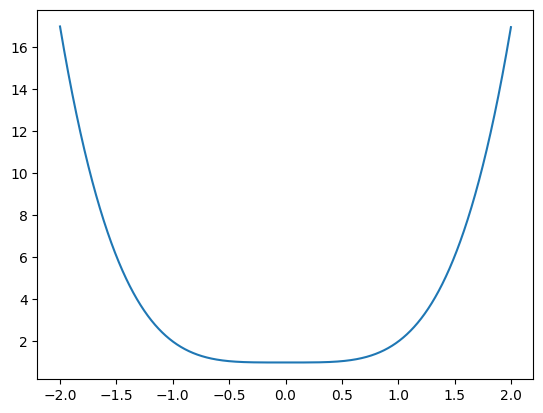

In [112]:
w = np.arange(-2, 2, 0.001)
f = w ** 4 + 1

plt.plot(w, f)
plt.show()

In [113]:
def gradient_descent_momentum(f, df, learning_rate, num_steps, w_0, window_size=100):
    losses = []      # завели массив значений функции потерь
    ws = [w_0]       # массив шагов
    grads = []       # массив градиентов
    w_cur = w_0
    for step in range(num_steps):
        loss_step = f(w_cur)
        g = df(w_cur)
        grads.append(g)
        if len(grads) >= window_size:
            v = learning_rate * (g + np.mean(grads[-window_size:]))
        else:
            v = learning_rate * (g + np.mean(grads))
        w_cur = w_cur - v
        losses.append(loss_step)
        ws.append(w_cur)
    losses.append(f(w_cur))
    return losses, ws, w_cur

In [114]:
def f(w):
    return w ** 4 + 1

def df(w):
    return 4 * w ** 3

In [115]:
loss, ws, w = gradient_descent(f, df, 0.01, 1000, 1.5)
loss_naive_momentum, ws_naive_momentum, w_naive_momentum = gradient_descent_momentum(f, df, 0.01, 1000, 1.5)

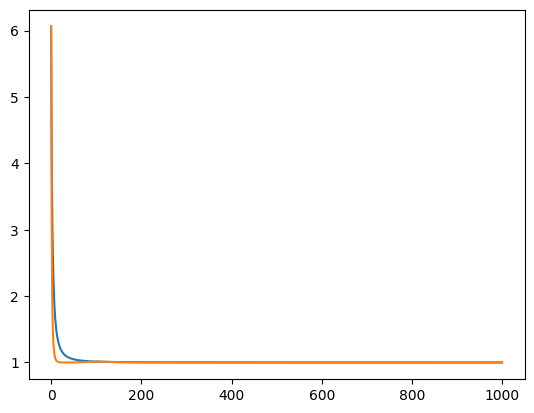

In [116]:
plt.plot(loss)
plt.plot(loss_naive_momentum)

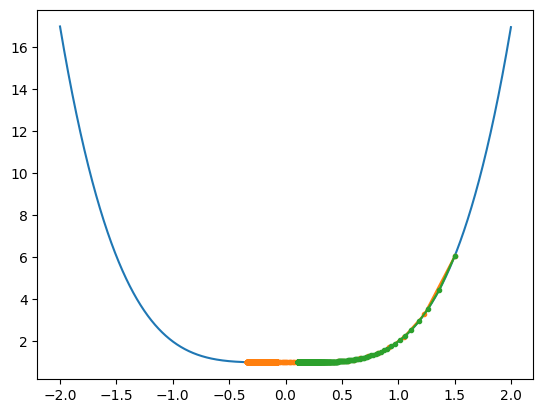

In [117]:
w = np.arange(-2, 2, 0.001)
y = f(w)
plt.plot(w,y)
plt.plot(ws_naive_momentum, loss_naive_momentum, marker='.')
plt.plot(ws, loss, marker='.')

In [118]:
 loss, _, w = gradient_descent_momentum(f, df, 0.01, 2000, np.random.random(), 100)

## Задача 4. Momentum

Замените хранение всех градиентов на экспоненциальное среднее.

In [124]:
def gradient_descent_momentum(f, df, learning_rate, num_steps, w_0, b):
    losses = []      #массив значений функции потерь
    ws = [w_0]       #массив шагов
    momentums = []       #массив градиентов
    w_cur = w_0
    v_cur= 0.0
    for step in range(num_steps):
        loss_step = f(w_cur)
        g = df(w_cur)
        v_cur = b*v_cur-learning_rate*g
        momentums.append(v_cur)
        w_cur = w_cur + v_cur
        losses.append(loss_step)
        ws.append(w_cur)
    losses.append(f(w_cur))
    return losses, ws, w_cur

In [125]:
 loss, ws, w= gradient_descent_momentum(f, df, 0.01, 100, 1.5, 0.8)

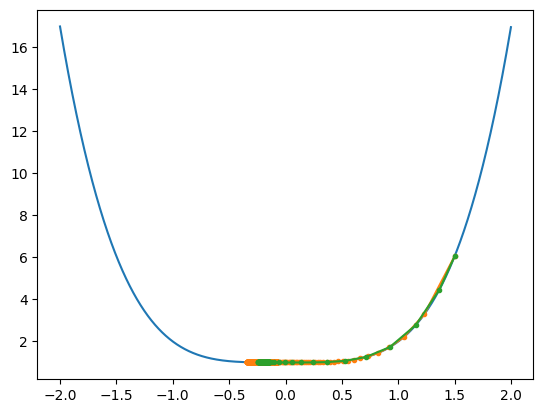

In [126]:
w = np.arange(-2, 2, 0.001)
y = f(w)
plt.plot(w,y)
plt.plot(ws_naive_momentum, loss_naive_momentum, marker='.')
plt.plot(ws, loss, marker='.')

In [127]:
def gradient_descent_momentum_real(f, df, learning_rate, num_steps, w_0, alpha=0.9):
    losses = []
    ws = [w_0]
    w_cur = w_0
    v_cur = 0.0

    for step in range(num_steps):
        loss_step = f(w_cur)
        g = df(w_cur)

        v_cur = alpha * v_cur - learning_rate * g
        w_cur = w_cur + v_cur

        losses.append(loss_step)
        ws.append(w_cur)

    losses.append(f(w_cur))
    return losses, w_cur

In [128]:
#Определяем начальную точку
w_0 = 1.5

loss, w = gradient_descent_momentum_real(f, fd, 0.01, 500, w_0, alpha=0.90)

## Задача 5. Напишите градиентный спуск для двумерной функции



In [129]:
def f(w):
    return w[0] ** 2 + w[1] ** 2

def gradient(w):
    return np.array([2* w[0], 2 * w[1]])

In [130]:
def gradient_descent_2d(f, gradient, learning_rate, num_steps, w_0):

    losses = []
    ws = [w_0.copy()]
    w_cur = w_0.copy()

    for step in range(num_steps):
        loss_step = f(w_cur)
        grad = gradient(w_cur)
        w_cur = w_cur - learning_rate * grad
        losses.append(loss_step)
        ws.append(w_cur.copy())

    losses.append(f(w_cur))
    return losses, ws, w_cur

In [131]:
#Тестируем
losses, trajectory, final = gradient_descent_2d(f, gradient, 0.1, 50, np.array([1.5, 1.5]))

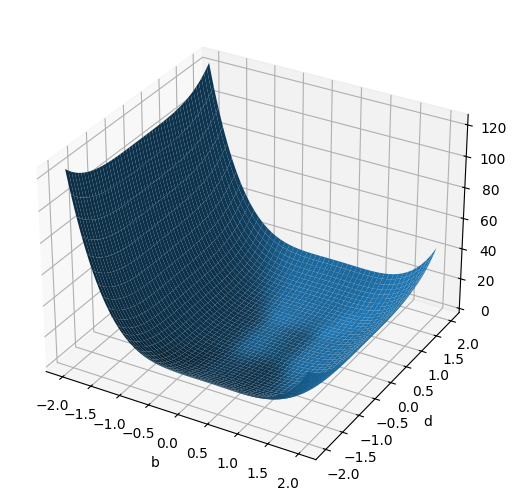

In [132]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

b = np.arange(-2, 2, 0.01)
d = np.arange(-2, 2.0, 0.01)

X, Y = np.meshgrid(b, d)
nu = 4 * X ** 4 + Y ** 4 - 5 * X ** 3 + X ** 2

fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.plot_surface(X, Y, nu)
plt.xlabel('b')
plt.ylabel('d')
plt.show()

Оцените, как он будет работать для следующей функци

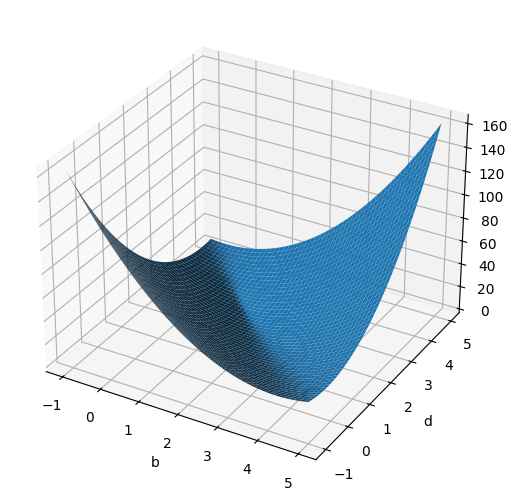

In [133]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

b = np.arange(-1, 5, 0.01)
d = np.arange(-1, 5.0, 0.01)

X, Y = np.meshgrid(b, d)
nu = (X + 2 * Y - 7) ** 2 + (2 * X + Y - 5) ** 2

fig = plt.figure()
ax = Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)
ax.plot_surface(X, Y, nu)
plt.xlabel('b')
plt.ylabel('d')
plt.show()

Оцените, как он будет работать для такой функции

In [134]:
def f(w):
    return w[0] ** 2 - w[1] ** 2

def gradient(w):
    return np.array(2* w[0], -2 * w[1])

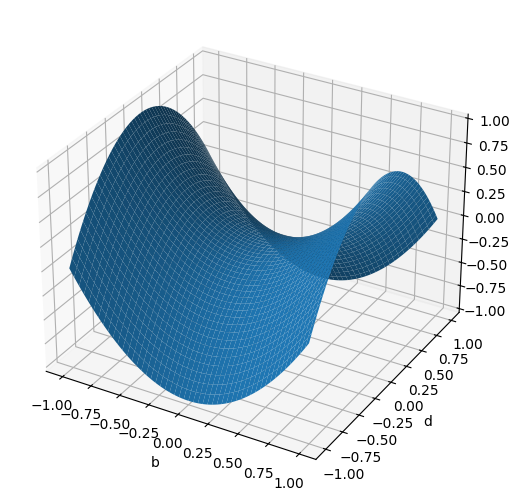

In [135]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

b = np.arange(-1, 1, 0.01)
d = np.arange(-1, 1.0, 0.01)

X, Y = np.meshgrid(b, d)
nu = X ** 2 - Y ** 2

fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.plot_surface(X, Y, nu)
plt.xlabel('b')
plt.ylabel('d')
plt.show()

**Вывод:**

1) Получается, для первого теста с простой параболой - это идеальный случай для градиентногго спуска, он находит успе6шно глобальный мимнимум

2) Во втором случе со сдвинутой квадратичной функции есть коррелиция между переменными, но сходится медленее

3) В третьем случае(седло) градиен6тный спуск е работает, алгоритм расходится, по x cходится к 0, а по y в плюс/минус бесконечность(расходится)

Таким образом, градиентный спуск эффективен только для выпуклых функций.